# Business Entity Resolution: data, preprocessing and analytics

This notebook visualises the challenge data and every processing step of our solution:

1. **Raw data**: sizes, countries, first rows
2. **Ground truth**: how many matches a business has, and the one-owner property
3. **Data quality and noise**: missing addresses, scripts, domains, shared name vocabulary
4. **Preprocessing**: normalisation, consonant skeletons, word segmentation, and their effect on true pairs
5. **Candidate generation (blocking)**: recall@k by channel, candidates per record, the funnel
6. **Features**: how true and false pairs separate
7. **Models and decision**: feature importance, calibration, decision rules
8. **Results**: macro F0.5 overall and by segment, error slices, test predictions (incl. France)
9. **Worked example**: Tirupati Power end to end

It reads the raw TSV-derived parquet files and the cached artefacts that `prepare.py` and
`run_pipeline.py` write to `work/`. Run those first. Heavy tables are sampled
deterministically (`idx % N == 0`) so the notebook fits in a few GB of RAM.

In [1]:
import os, sys, json, pickle, glob, unicodedata
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
from config import ROOT, DATA_DIR, WORK_DIR, OUT_DIR
from common import load_gt_pairs, macro_f05, norm_path
from normalize import process_record, skeleton, norm_name, norm_address, Segmenter, resegment
from decision import one_to_one, select_matches, threshold_matches, expected_f_best_k

pl.Config.set_tbl_width_chars(200); pl.Config.set_fmt_str_lengths(70); pl.Config.set_tbl_rows(25)
print('ROOT =', ROOT); print('WORK =', WORK_DIR)

# ---- chart style: validated reference palette, recessive grid, thin marks
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, INK2, GRID, SURF = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': INK2, 'ytick.color': INK2, 'axes.grid': True, 'grid.color': GRID,
    'grid.linewidth': 0.8, 'axes.axisbelow': True, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titleweight': 'bold', 'axes.titlesize': 11,
    'axes.titlelocation': 'left', 'font.size': 9.5, 'legend.frameon': False,
    'figure.dpi': 110,
})
COUNTRY_COLOR = {'US': BLUE, 'India': ORANGE, 'France': AQUA}
SOURCE_COLOR = {'S1': BLUE, 'S2': ORANGE, 'S3': AQUA}
pct = PercentFormatter(1.0, decimals=0)
thousands = FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else (f'{v/1e3:.0f}k' if v >= 1e3 else f'{v:.0f}'))

def label_bars(ax, bars, fmt='{:.1%}', inside=False, color=INK):
    for b in bars:
        v = b.get_height()
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                    textcoords='offset points', ha='center', va='bottom', fontsize=8, color=color)

def raw(split, s):
    return pl.scan_parquet(os.path.join(WORK_DIR, f'{split}_s{s}.parquet'))

ROOT = D:\amazon
WORK = D:\amazon\work


## 1. Raw data

Each source file has `entity_id`, `business_name`, `business_address` and `country`. The
source is given only by the ID prefix (`S1-`, `S2-`, `S3-`).

In [2]:
rows = []
for split in ('train', 'test'):
    for s in (1, 2, 3):
        rows.append({'split': split, 'source': f'S{s}',
                     'records': raw(split, s).select(pl.len()).collect().item()})
sizes = pl.DataFrame(rows)
gt_raw = pl.read_csv(os.path.join(DATA_DIR, 'train', 'train_ground_truth.tsv'), separator='\t',
                     quote_char=None, infer_schema=False)
print(sizes.pivot(on='split', index='source', values='records'))
print('ground-truth rows (= train S1 entities):', gt_raw.height)

shape: (3, 3)
┌────────┬─────────┬─────────┐
│ source ┆ train   ┆ test    │
│ ---    ┆ ---     ┆ ---     │
│ str    ┆ i64     ┆ i64     │
╞════════╪═════════╪═════════╡
│ S1     ┆ 2206821 ┆ 1732544 │
│ S2     ┆ 5034616 ┆ 4887273 │
│ S3     ┆ 5285603 ┆ 5082316 │
└────────┴─────────┴─────────┘
ground-truth rows (= train S1 entities): 2206821


In [3]:
for s in (1, 2, 3):
    print(f'--- train source {s}')
    print(raw('train', s).head(4).collect())

--- train source 1
shape: (4, 4)
┌──────────────┬─────────────────────┬───────────────────────────────────────────────────┬─────────┐
│ entity_id    ┆ business_name       ┆ business_address                                  ┆ country │
│ ---          ┆ ---                 ┆ ---                                               ┆ ---     │
│ str          ┆ str                 ┆ str                                               ┆ str     │
╞══════════════╪═════════════════════╪═══════════════════════════════════════════════════╪═════════╡
│ S1-925783039 ┆ Orelee's Barbershop ┆ 1795 Westchester Drive, High Point, NC            ┆ US      │
│ S1-773889195 ┆ Prime Money         ┆ 17560 Ellis Road, Tahlequah, OK                   ┆ US      │
│ S1-377745466 ┆ B+ Retail Inc       ┆ 1712 Montebello Avenue, Phoenix, AZ               ┆ US      │
│ S1-133037285 ┆ Christ Chapel       ┆ 2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD ┆ US      │
└──────────────┴─────────────────────┴────────────────────

### Countries per source
The test set adds **France**, which never appears in training.

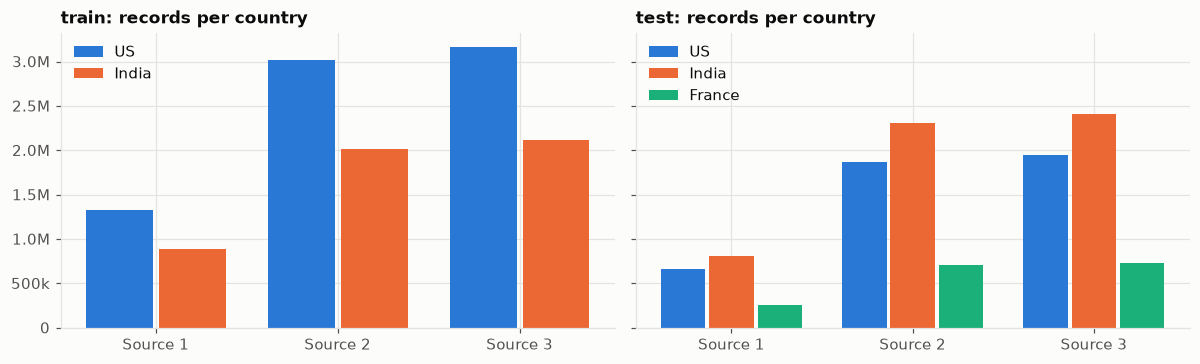

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, split in zip(axes, ('train', 'test')):
    tab = pl.concat([raw(split, s).group_by('country').agg(pl.len().alias('n'))
                       .with_columns(pl.lit(f'S{s}').alias('src')) for s in (1, 2, 3)]).collect()
    countries = [c for c in ('US', 'India', 'France') if c in tab['country'].to_list()]
    x = np.arange(3); w = 0.8 / len(countries)
    for i, c in enumerate(countries):
        vals = [tab.filter((pl.col('src') == f'S{s}') & (pl.col('country') == c))['n'].sum() for s in (1, 2, 3)]
        bars = ax.bar(x + (i - (len(countries) - 1) / 2) * w, vals, w * 0.92, color=COUNTRY_COLOR[c], label=c)
    ax.set_xticks(x, ['Source 1', 'Source 2', 'Source 3']); ax.yaxis.set_major_formatter(thousands)
    ax.set_title(f'{split}: records per country'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 2. Ground truth structure

`train_ground_truth.tsv` lists, for each S1 entity, its matching S2/S3 IDs (empty for
singletons). Below we explode it into pairs.

In [5]:
gt = load_gt_pairs().cast({'s1_idx': pl.UInt32, 'ot_idx': pl.UInt32})
s1_meta = pl.scan_parquet(norm_path('train', 's1')).select(pl.col('idx').cast(pl.UInt32), 'country').collect()
ot_meta = pl.scan_parquet(norm_path('train', 'oth')).select(pl.col('idx').cast(pl.UInt32), 'src', 'country').collect()
n_s1, n_ot = s1_meta.height, ot_meta.height

per = (s1_meta.rename({'idx': 's1_idx'})
       .join(gt.join(ot_meta.rename({'idx': 'ot_idx'}), on='ot_idx')
               .group_by('s1_idx').agg(pl.len().alias('n'), (pl.col('src') == 'S2').sum().alias('n2'),
                                       (pl.col('src') == 'S3').sum().alias('n3')),
             on='s1_idx', how='left').fill_null(0))
owners = gt.group_by('ot_idx').len()
print(f'true pairs: {gt.height:,}')
print(f'singletons (no match): {(per["n"] == 0).sum():,} = {(per["n"] == 0).mean():.2%}')
print(f'mean matches per entity: {per["n"].mean():.2f}')
print(f'max S1 owners per S2/S3 record: {owners["len"].max()}  -> one owner per record')
print(f'S2/S3 records that match some S1: {owners.height / n_ot:.1%}  (the rest are distractors)')
chk = gt.join(s1_meta.rename({'idx': 's1_idx', 'country': 'c1'}), on='s1_idx').join(
      ot_meta.rename({'idx': 'ot_idx', 'country': 'c2'}), on='ot_idx')
print(f'country agrees in {(chk["c1"] == chk["c2"]).mean():.2%} of true pairs')

true pairs: 7,638,365
singletons (no match): 123,247 = 5.58%
mean matches per entity: 3.46
max S1 owners per S2/S3 record: 1  -> one owner per record
S2/S3 records that match some S1: 74.0%  (the rest are distractors)


country agrees in 100.00% of true pairs


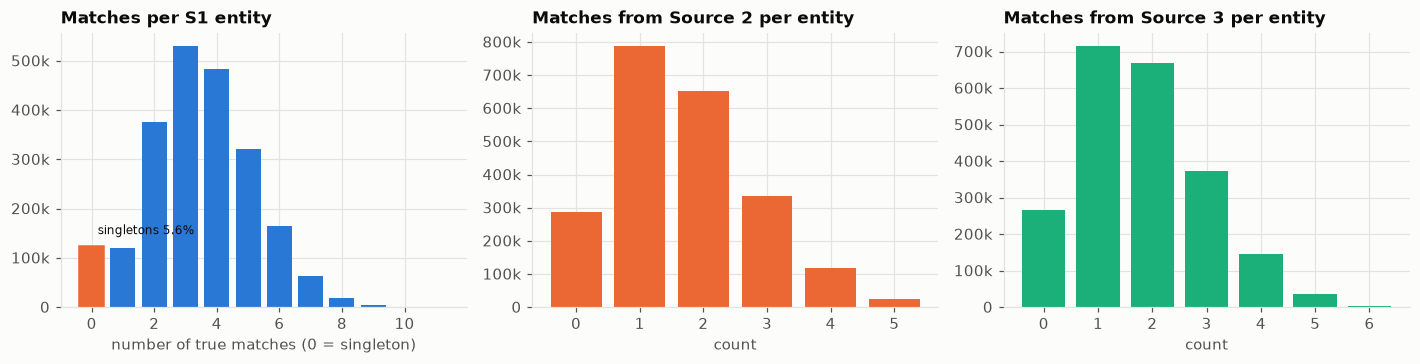

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
vc = per['n'].value_counts().sort('n')
bars = axes[0].bar(vc['n'], vc['count'], 0.8, color=BLUE)
bars[0].set_color(ORANGE)
axes[0].set_title('Matches per S1 entity'); axes[0].set_xlabel('number of true matches (0 = singleton)')
axes[0].yaxis.set_major_formatter(thousands)
axes[0].annotate('singletons 5.6%', (0, vc['count'][0]), xytext=(4, 8), textcoords='offset points', fontsize=8)
for ax, col, src in ((axes[1], 'n2', 'Source 2'), (axes[2], 'n3', 'Source 3')):
    v = per[col].value_counts().sort(col)
    ax.bar(v[col], v['count'], 0.8, color=SOURCE_COLOR['S2' if col == 'n2' else 'S3'])
    ax.set_title(f'Matches from {src} per entity'); ax.set_xlabel('count'); ax.yaxis.set_major_formatter(thousands)
plt.tight_layout(); plt.show()

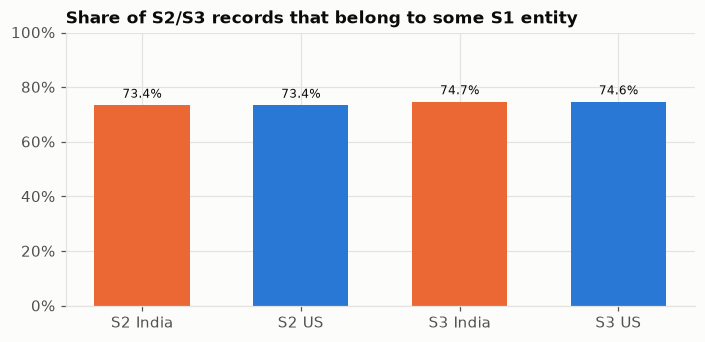

About a quarter of S2/S3 records are distractors that must stay unmatched.


In [7]:
m = ot_meta.rename({'idx': 'ot_idx'}).join(owners.select('ot_idx', pl.lit(True).alias('matched')), on='ot_idx', how='left') \
          .with_columns(pl.col('matched').fill_null(False))
tab = m.group_by('src', 'country').agg(pl.col('matched').mean().alias('rate'), pl.len()).sort('src', 'country')
fig, ax = plt.subplots(figsize=(6.5, 3.2))
labels = [f"{r['src']} {r['country']}" for r in tab.iter_rows(named=True)]
bars = ax.bar(labels, tab['rate'], 0.6, color=[COUNTRY_COLOR[c] for c in tab['country']])
label_bars(ax, bars); ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(pct)
ax.set_title('Share of S2/S3 records that belong to some S1 entity')
plt.tight_layout(); plt.show()
print('About a quarter of S2/S3 records are distractors that must stay unmatched.')

## 3. Data quality and noise

Measured on a deterministic 1/10 sample of records.

shape: (6, 5)
┌─────┬─────────┬──────────┬──────────┬──────────┐
│ src ┆ country ┆ no_addr  ┆ nonlatin ┆ is_dom   │
│ --- ┆ ---     ┆ ---      ┆ ---      ┆ ---      │
│ str ┆ str     ┆ f64      ┆ f64      ┆ f64      │
╞═════╪═════════╪══════════╪══════════╪══════════╡
│ S1  ┆ India   ┆ 0.0      ┆ 0.0      ┆ 0.0      │
│ S2  ┆ India   ┆ 0.028081 ┆ 0.234968 ┆ 0.028769 │
│ S3  ┆ India   ┆ 0.030479 ┆ 0.132107 ┆ 0.030635 │
│ S1  ┆ US      ┆ 0.0      ┆ 0.0      ┆ 0.0      │
│ S2  ┆ US      ┆ 0.036795 ┆ 0.0      ┆ 0.040878 │
│ S3  ┆ US      ┆ 0.035014 ┆ 0.0      ┆ 0.039703 │
└─────┴─────────┴──────────┴──────────┴──────────┘


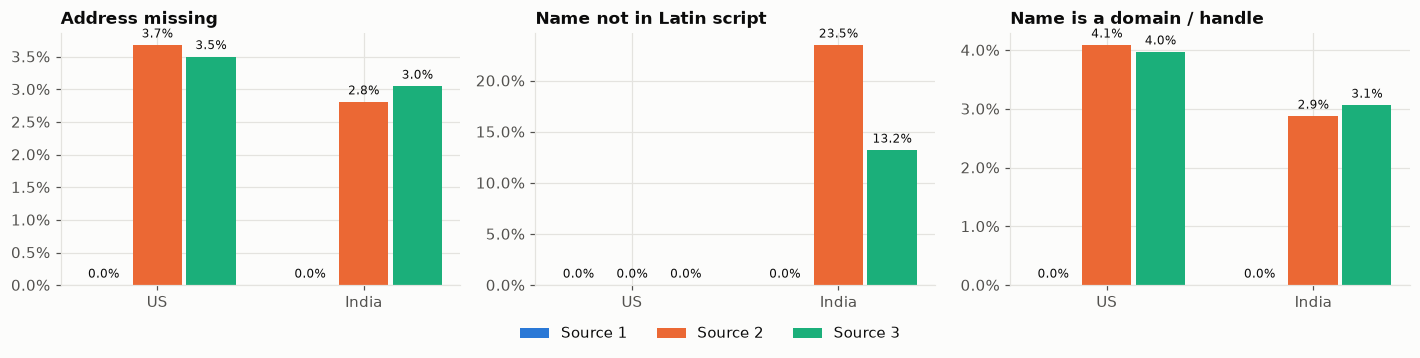

Source 1 is clean: every S1 record has a Latin-script name and an address.


In [8]:
NONLATIN = r'[^\x00-\x7F\u00C0-\u024F\u2000-\u206F]'
def quality(split, part):
    return (pl.scan_parquet(norm_path(split, part)).filter(pl.col('idx') % 10 == 0)
              .select('src', 'country', 'business_name', 'business_address', 'is_dom', 'ad', 'nm').collect()
              .with_columns((pl.col('ad') == '').alias('no_addr'),
                            pl.col('business_name').str.contains(NONLATIN).alias('nonlatin')))
q = pl.concat([quality('train', 's1'), quality('train', 'oth')])
stats = q.group_by('src', 'country').agg(pl.col('no_addr').mean(), pl.col('nonlatin').mean(),
                                          pl.col('is_dom').mean()).sort('country', 'src')
print(stats)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=False)
for ax, col, title in zip(axes, ('no_addr', 'nonlatin', 'is_dom'),
                          ('Address missing', 'Name not in Latin script', 'Name is a domain / handle')):
    x = np.arange(2); w = 0.26
    for i, s in enumerate(('S1', 'S2', 'S3')):
        vals = [stats.filter((pl.col('src') == s) & (pl.col('country') == c))[col].sum() for c in ('US', 'India')]
        bars = ax.bar(x + (i - 1) * w, vals, w * 0.92, color=SOURCE_COLOR[s], label=s)
        label_bars(ax, bars, '{:.1%}')
    ax.set_xticks(x, ['US', 'India']); ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1)); ax.set_title(title)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, ['Source 1', 'Source 2', 'Source 3'], loc='lower center', ncols=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()
print('Source 1 is clean: every S1 record has a Latin-script name and an address.')

### Which scripts appear in Indian names?

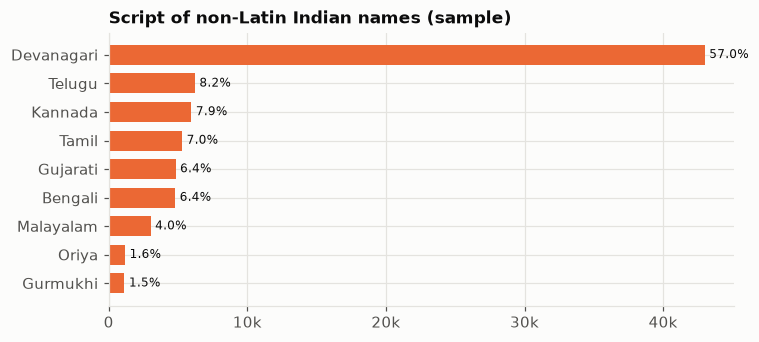

Examples: ['राम मार्केटिंग प्राइवेट लिमिटेड', 'अल्फा अल टेक्नोलॉजीज प्राइवेट लिमिटेड', 'হাইটেক ইনফ্রা প্রাইভেট লিমিটেড', 'శ్రీ ఆగ్రో ప్రైవేట్ లిమిటెడ్', 'ब्राइट फाइनेंस प्राइवेट लिमिटेड', 'Shree ਫਿਊਚਰ Estate ਪ੍ਰਾ. ਲਿ.']


In [9]:
def script_of(s):
    for ch in s:
        if ord(ch) > 0x24F:
            try:
                return unicodedata.name(ch).split(' ')[0].title()
            except ValueError:
                return 'Other'
    return 'Latin'
nl = q.filter(pl.col('nonlatin') & (pl.col('country') == 'India'))['business_name'].to_list()
sc = pl.DataFrame({'script': [script_of(s) for s in nl]}).group_by('script').len().sort('len')
fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh(sc['script'], sc['len'], 0.7, color=ORANGE)
for b in bars:
    ax.annotate(f'{b.get_width()/sc["len"].sum():.1%}', (b.get_width(), b.get_y() + b.get_height()/2),
                xytext=(3, 0), textcoords='offset points', va='center', fontsize=8)
ax.set_title('Script of non-Latin Indian names (sample)'); ax.xaxis.set_major_formatter(thousands)
plt.tight_layout(); plt.show()
print('Examples:', nl[:6])

### Names reuse a shared vocabulary

A key finding: individual name words are common, so identity lives in **combinations**
of words. The chart shows, for every S1 name, how many S1 records contain its *rarest*
word.

C:\Users\Admin\AppData\Local\Temp\ipykernel_7000\2735315845.py:2: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  tok = s1n.select('idx', 'country', pl.col('nm').str.split(' ').alias('t')).explode('t').filter(pl.col('t') != '')


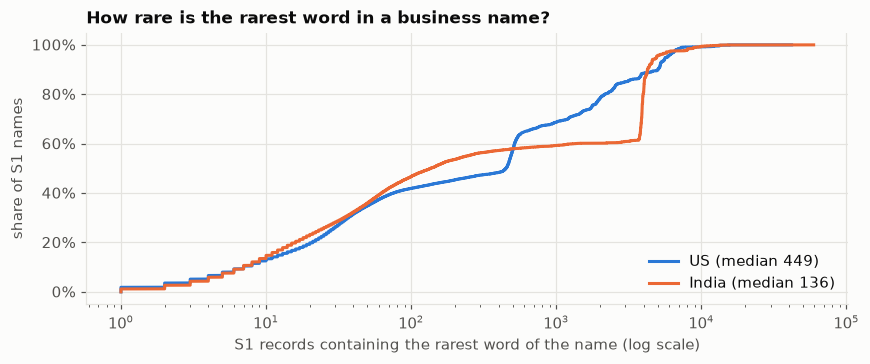

Most repeated normalised names in Source 1:
shape: (10, 2)
┌───────────────┬─────┐
│ nm            ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ meridian      ┆ 575 │
│ cedar         ┆ 352 │
│ summit        ┆ 338 │
│ family center ┆ 337 │
│ cascade       ┆ 334 │
│ helios        ┆ 334 │
│ sterling      ┆ 327 │
│ granite       ┆ 325 │
│ lynx          ┆ 319 │
│ sapphire      ┆ 317 │
└───────────────┴─────┘
Exact name "tirupati power": 69 different S1 entities


In [10]:
s1n = pl.scan_parquet(norm_path('train', 's1')).select('idx', 'nm', 'country').collect()
tok = s1n.select('idx', 'country', pl.col('nm').str.split(' ').alias('t')).explode('t').filter(pl.col('t') != '')
df_ = tok.group_by('country', 't').agg(pl.len().alias('df'))
rare = tok.join(df_, on=['country', 't']).group_by('idx', 'country').agg(pl.col('df').min())
fig, ax = plt.subplots(figsize=(8, 3.4))
for c in ('US', 'India'):
    v = np.sort(rare.filter(pl.col('country') == c)['df'].to_numpy())
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=COUNTRY_COLOR[c], lw=2, label=f'{c} (median {int(np.median(v))})')
ax.set_xscale('log'); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel('S1 records containing the rarest word of the name (log scale)')
ax.set_ylabel('share of S1 names'); ax.set_title('How rare is the rarest word in a business name?')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
top = s1n.group_by('nm').len().sort('len', descending=True).head(10)
print('Most repeated normalised names in Source 1:'); print(top)
print('Exact name "tirupati power":', s1n.filter(pl.col('nm') == 'tirupati power').height, 'different S1 entities')

### A real matched group

In [11]:
def show_group(s1_idx):
    a = pl.scan_parquet(norm_path('train', 's1')).filter(pl.col('idx') == s1_idx).select(
        'entity_id', 'business_name', 'business_address').collect()
    ids = gt.filter(pl.col('s1_idx') == s1_idx)['ot_idx']
    b = pl.scan_parquet(norm_path('train', 'oth')).filter(pl.col('idx').is_in(ids.implode())).select(
        'entity_id', 'business_name', 'business_address').collect()
    print(pl.concat([a, b]))
show_group(1096)   # Tirupati Power, New Delhi
show_group(2238)   # Guru Energy, Bangalore (Kannada script)

shape: (5, 3)
┌──────────────┬─────────────────┬──────────────────────────────────────────────────────────────────┐
│ entity_id    ┆ business_name   ┆ business_address                                                 │
│ ---          ┆ ---             ┆ ---                                                              │
│ str          ┆ str             ┆ str                                                              │
╞══════════════╪═════════════════╪══════════════════════════════════════════════════════════════════╡
│ S1-271585788 ┆ Tirupati Power  ┆ West Delhi, Wz-2D, New Delhi, Nangli Zalib B-1 Janak Puri, Delhi │
│ S2-139796834 ┆ तिरुपति पावर     ┆ WZ-2D, NANGLI ZALIB B-1 JANAK PURI, WEST DELHI, NEW DELHI, Delhi │
│ S3-103238828 ┆ Tirupati Power  ┆ Wz-2d, Nangli Zalib B-1 Janak Puri, West Delhi, New Delhi, दिल्ली │
│ S3-31728409  ┆ Tirupati  Power ┆ Wz-2d, Nangli Zalib B-1 Janak Puri, New Delhi, West Delhi, DL    │
│ S3-219339349 ┆ तिरुपति पावर     ┆ Wz-2d, West Delhi, DL, New Del

## 4. Preprocessing

`normalize.py` turns each record into comparable fields:

| field | content |
|---|---|
| `nm` | core name: transliterated, lower-case, legal suffixes and stop-words removed, duplicates dropped |
| `legal` | canonical legal forms (`pvt`, `ltd`, `llc`, `sarl`, …) |
| `nsk` | consonant skeleton of each name word (cross-script matching) |
| `ad` | address words with abbreviations canonicalised, state removed, leading zeros stripped |
| `nums` | numbers in the address (plus joined digit groups, "29-04" → "2904") |
| `state` | state code from full names, codes or Indic-script names |

In [12]:
examples = [
    ('Tirupati Power', 'West Delhi, Wz-2D, New Delhi, Nangli Zalib B-1 Janak Puri, Delhi'),
    ('तिरुपति पावर', 'WZ-2D, NANGLI ZALIB B-1 JANAK PURI, WEST DELHI, NEW DELHI, Delhi'),
    ('One Marketing L.L.P.', '2904 Karehra, Mohan Nagar, Ghaziabad, Uttar Pradesh'),
    ('वन मार्केटिंग एलएलपी', 'H.NO 29-04 KAREHRA, GHAZIABAD, MOHAN NAGAR, उत्तर प्रदेश'),
    ('ÍNC COYNE INSTITUTE OF TECHNOLOGY', '503 CLINTON SAINT, BLOOMINGTON, IL'),
    ('Urology Service', '02714 Jarvis Saint, Decatur, Alabama'),
    ('Kdanse &-Cie SARL', 'CALAIS, Pas-de-Calais, (31) RUE VAN GRUTTEN'),
]
cols = ['nm', 'legal', 'nsk', 'is_dom', 'nonlatin', 'ad', 'nums', 'state', 'comps']
rows = [dict(zip(['raw_name', 'raw_address'], e), **dict(zip(cols, process_record(*e)))) for e in examples]
print(pl.DataFrame(rows).select('raw_name', 'nm', 'legal', 'nsk', 'ad', 'nums', 'state'))

shape: (7, 7)
┌───────────────────────────────────┬────────────────────────────┬─────────┬──────────────┬─────────────────────────────────────────────────────┬───────────┬───────┐
│ raw_name                          ┆ nm                         ┆ legal   ┆ nsk          ┆ ad                                                  ┆ nums      ┆ state │
│ ---                               ┆ ---                        ┆ ---     ┆ ---          ┆ ---                                                 ┆ ---       ┆ ---   │
│ str                               ┆ str                        ┆ str     ┆ str          ┆ str                                                 ┆ str       ┆ str   │
╞═══════════════════════════════════╪════════════════════════════╪═════════╪══════════════╪═════════════════════════════════════════════════════╪═══════════╪═══════╡
│ Tirupati Power                    ┆ tirupati power             ┆         ┆ trpt pvr     ┆ w delhi wz 2d new delhi nangli zalib b 1 janak puri ┆ 2 1       

**Consonant skeleton.** Digraphs are folded (ph→f, bh→b, sh→s, c/q→k, w→v, …), repeated
letters collapsed, and vowels, `h` and `y` removed. The romanised Devanagari and the
English spelling land on the same key:

In [13]:
for a, b in [('marketing', 'maarkettiNg'), ('tirupati', 'tirupti'), ('power', 'paavr'),
             ('private', 'praaivett'), ('limited', 'limittedd'), ('consultancy', 'knslttensii')]:
    print(f'{a:>12} -> {skeleton(a):<8} | {b:>12} -> {skeleton(b.lower())}')

   marketing -> mrktng   |  maarkettiNg -> mrktng
    tirupati -> trpt     |      tirupti -> trpt
       power -> pvr      |        paavr -> pvr
     private -> prvt     |    praaivett -> prvt
     limited -> lmtd     |    limittedd -> lmtd
 consultancy -> knsltnk  |  knslttensii -> knsltns


**Word segmentation.** Domain names and handles glue words together. A unigram Viterbi
segmenter learned from the Source 1 names splits them. A split is accepted only if every
piece is a known word of three or more letters, so typos are left alone.

In [14]:
from prepare import build_segmenter
seg = build_segmenter(s1n)
for t in ['raamvallalarprivate', 'greatmanagementcom', 'pioneerproperties', 'suarezenterprisesgroup',
          'consuihancy', 'asgsistance']:
    r = resegment(t, '', seg)
    print(f'{t:>24} -> {r[0] if r else "(kept as is: not a clean concatenation)"}')

     raamvallalarprivate -> raam vallalar
      greatmanagementcom -> great management
       pioneerproperties -> pioneer properties
  suarezenterprisesgroup -> suarez enterprises group
             consuihancy -> (kept as is: not a clean concatenation)
             asgsistance -> (kept as is: not a clean concatenation)


### Effect of preprocessing on true pairs

We compare true pairs with random *same-country* non-matching pairs (1/20 sample). The
further apart the two distributions, the easier the matching.

C:\Users\Admin\AppData\Local\Temp\ipykernel_7000\1535427429.py:13: DeprecationWarning: the default behavior of `how='horizontal'` for `concat` is deprecated and will require equal heights in the next breaking release. Use `how='horizontal_extend'` to keep the current behavior.
(Deprecated in version 1.42.1)
  neg = pl.concat([neg.sort('perm').drop('perm'), negb], how='horizontal').filter(pl.col('country_a') == pl.col('country_b'))


raw names identical:        4.6% of true pairs
normalised names identical: 55.6% of true pairs
skeletons identical:        59.6% of true pairs


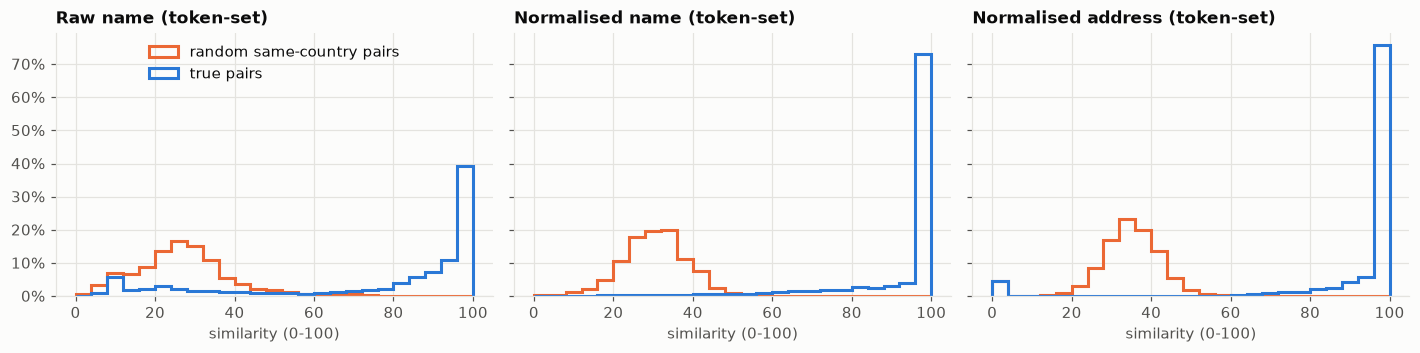

The small spike at 0 in the address panel is true pairs whose S2/S3 record has no address.


In [15]:
from rapidfuzz import process, fuzz
S = 20
gts = gt.filter(pl.col('ot_idx') % S == 0)
cols_ = ['idx', 'business_name', 'business_address', 'nm', 'nsk', 'ad', 'country']
A = pl.scan_parquet(norm_path('train', 's1')).select(cols_).filter(pl.col('idx').is_in(gts['s1_idx'].implode())).collect().cast({'idx': pl.UInt32})
B = pl.scan_parquet(norm_path('train', 'oth')).select(cols_).filter(pl.col('idx') % S == 0).collect().cast({'idx': pl.UInt32})
pos = gts.join(A.rename(lambda c: c + '_a' if c != 'idx' else 's1_idx'), on='s1_idx').join(
      B.rename(lambda c: c + '_b' if c != 'idx' else 'ot_idx'), on='ot_idx')
rng = np.random.default_rng(0)
neg = pos.select([c for c in pos.columns if c.endswith('_a')]).with_columns(
      pl.Series('perm', rng.permutation(pos.height)))
negb = pos.select([c for c in pos.columns if c.endswith('_b')])
neg = pl.concat([neg.sort('perm').drop('perm'), negb], how='horizontal').filter(pl.col('country_a') == pl.col('country_b'))
def sim(df, a, b, scorer=fuzz.token_set_ratio):
    return process.cpdist(df[a].fill_null('').to_list(), df[b].fill_null('').to_list(), scorer=scorer, workers=-1)
print(f'raw names identical:        {(pos["business_name_a"] == pos["business_name_b"]).mean():.1%} of true pairs')
print(f'normalised names identical: {(pos["nm_a"] == pos["nm_b"]).mean():.1%} of true pairs')
print(f'skeletons identical:        {(pos["nsk_a"] == pos["nsk_b"]).mean():.1%} of true pairs')
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
bins = np.linspace(0, 100, 26)
for ax, (a, b, title) in zip(axes, [('business_name_a', 'business_name_b', 'Raw name (token-set)'),
                                     ('nm_a', 'nm_b', 'Normalised name (token-set)'),
                                     ('ad_a', 'ad_b', 'Normalised address (token-set)')]):
    ax.hist(sim(neg, a, b), bins, histtype='step', lw=2, color=ORANGE, label='random same-country pairs', weights=np.full(neg.height, 1 / neg.height))
    ax.hist(sim(pos, a, b), bins, histtype='step', lw=2, color=BLUE, label='true pairs', weights=np.full(pos.height, 1 / pos.height))
    ax.set_title(title); ax.set_xlabel('similarity (0-100)'); ax.yaxis.set_major_formatter(pct)
axes[0].legend(loc='upper center'); plt.tight_layout(); plt.show()
print('The small spike at 0 in the address panel is true pairs whose S2/S3 record has no address.')

## 5. Candidate generation (blocking)

For every S2/S3 record we retrieve the most similar S1 records *in the same country*,
with sparse TF-IDF cosine over rare keys in three groups:

* **name**: words, skeletons, word pairs, 4-letter prefix pairs, skeleton pairs
* **address**: words, numbers, number + next word, adjacent word pairs
* **cross**: name word × house number

The candidates are the top 8 by the combined score, unioned with the top 3 by name, the
top 3 by address and the top 2 by cross. Below, recall@k per channel on a 1/20 sample.

sampled S2/S3 records: 514,743, candidate pairs: 5,102,668 (9.9 per record)


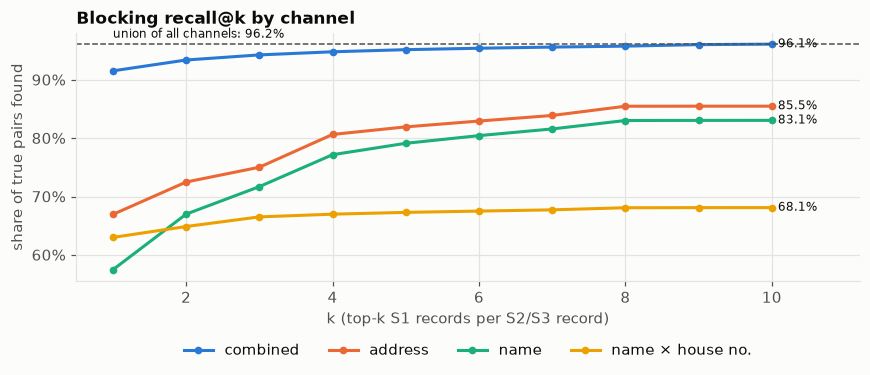

In [16]:
S = 20
cand = (pl.scan_parquet(os.path.join(WORK_DIR, 'train_cand', '*.parquet'))
          .filter(pl.col('ot_idx') % S == 0).select('s1_idx', 'ot_idx', 'sc_comb', 'sc_name', 'sc_addr', 'sc_mix').collect())
gts = gt.filter(pl.col('ot_idx') % S == 0)
print(f'sampled S2/S3 records: {cand["ot_idx"].n_unique():,}, candidate pairs: {cand.height:,} '
      f'({cand.height / cand["ot_idx"].n_unique():.1f} per record)')
ks = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(8, 3.6))
for ch, color, name in (('comb', BLUE, 'combined'), ('addr', ORANGE, 'address'), ('name', AQUA, 'name'), ('mix', YELLOW, 'name × house no.')):
    r = cand.filter(pl.col(f'sc_{ch}') > 0).with_columns(pl.col(f'sc_{ch}').rank('ordinal', descending=True).over('ot_idx').alias('rk'))
    j = gts.join(r.select('s1_idx', 'ot_idx', 'rk'), on=['s1_idx', 'ot_idx'], how='left')['rk'].to_numpy()
    rec = [(np.nan_to_num(j, nan=99) <= k).mean() for k in ks]
    ax.plot(ks, rec, color=color, lw=2, marker='o', ms=4, label=name)
    ax.annotate(f'{rec[-1]:.1%}', (ks[-1], rec[-1]), xytext=(4, 0), textcoords='offset points', va='center', fontsize=8)
union = gts.join(cand.select('s1_idx', 'ot_idx'), on=['s1_idx', 'ot_idx'], how='semi').height / gts.height
ax.axhline(union, color=INK2, lw=1, ls='--'); ax.annotate(f'union of all channels: {union:.1%}', (1, union), xytext=(0, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('k (top-k S1 records per S2/S3 record)'); ax.set_ylabel('share of true pairs found')
ax.yaxis.set_major_formatter(pct); ax.set_title('Blocking recall@k by channel')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncols=4)
ax.set_xlim(0.5, 11.2); plt.tight_layout(); plt.show()

### How the blocking design evolved

These were measured during development on the same 1/20 sample. Each row adds to the one
above.

| version | true pairs found | correct S1 ranked 1st |
|---|---|---|
| single tokens (name + address) | 78.0% | 65.9% |
| + name word pairs, address bigrams, name × house no. | 94.6% | 89.2% |
| + prefix pairs, skeleton cross keys, segmentation, leading-zero fix | 96.2% | 91.6% |

shape: (4, 3)
┌───────────────────────────────────┬──────────────┬────────────────┐
│ stage                             ┆ pairs        ┆ recall ceiling │
│ ---                               ┆ ---          ┆ ---            │
│ str                               ┆ f64          ┆ f64            │
╞═══════════════════════════════════╪══════════════╪════════════════╡
│ all S1 × S2/S3 pairs              ┆ 2.2775e13    ┆ 1.0            │
│ blocking candidates               ┆ 1.02044425e8 ┆ 0.961898       │
│ after prefilter (candidate_pairs) ┆ 1.7512544e7  ┆ 0.959893       │
│ true pairs                        ┆ 7.638365e6   ┆ null           │
└───────────────────────────────────┴──────────────┴────────────────┘


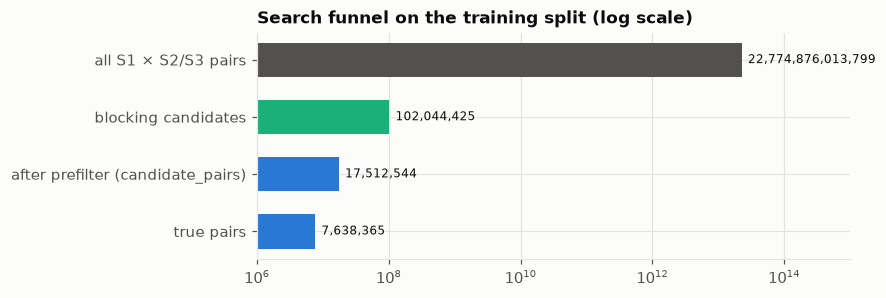

In [17]:
pf = pl.read_parquet(os.path.join(WORK_DIR, 'train_pf.parquet'), columns=['s1_idx', 'ot_idx'])
n_all = pl.scan_parquet(os.path.join(WORK_DIR, 'train_cand', '*.parquet')).select(pl.len()).collect().item()
rec_all = gt.join(pl.scan_parquet(os.path.join(WORK_DIR, 'train_cand', '*.parquet')).select('s1_idx', 'ot_idx').collect(),
                  on=['s1_idx', 'ot_idx'], how='semi').height / gt.height
rec_pf = gt.join(pf, on=['s1_idx', 'ot_idx'], how='semi').height / gt.height
funnel = pl.DataFrame({
    'stage': ['all S1 × S2/S3 pairs', 'blocking candidates', 'after prefilter (candidate_pairs)', 'true pairs'],
    'pairs': [float(n_s1) * n_ot, float(n_all), float(pf.height), float(gt.height)],
    'recall ceiling': [1.0, rec_all, rec_pf, None]})
print(funnel)
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(funnel['stage'][::-1], funnel['pairs'][::-1], 0.6, color=[INK2, AQUA, BLUE, BLUE][::-1])
ax.set_xscale('log'); ax.set_title('Search funnel on the training split (log scale)')
for b, v in zip(bars, funnel['pairs'][::-1]):
    ax.annotate(f'{v:,.0f}', (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(4, 0), textcoords='offset points', va='center', fontsize=8)
ax.set_xlim(1e6, 1e15); plt.tight_layout(); plt.show()

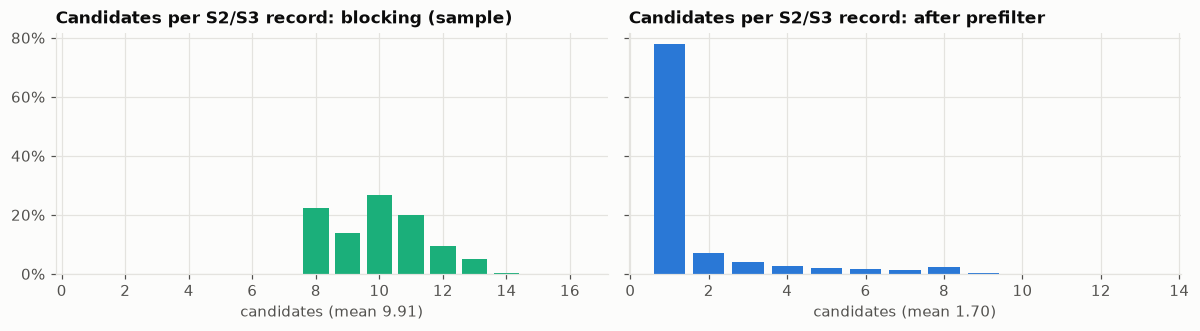

In [18]:
per_ot = pf.group_by('ot_idx').len()['len']
per_ot_block = cand.group_by('ot_idx').len()['len']
fig, axes = plt.subplots(1, 2, figsize=(11, 3.1), sharey=True)
for ax, v, title, color in ((axes[0], per_ot_block, 'Candidates per S2/S3 record: blocking (sample)', AQUA),
                            (axes[1], per_ot, 'Candidates per S2/S3 record: after prefilter', BLUE)):
    vc = v.value_counts().sort(v.name).filter(pl.col(v.name) <= 20)
    ax.bar(vc[v.name], vc['count'] / vc['count'].sum(), 0.8, color=color)
    ax.set_title(title); ax.yaxis.set_major_formatter(pct); ax.set_xlabel(f'candidates (mean {v.mean():.2f})')
plt.tight_layout(); plt.show()

## 6. Features: how true and false candidate pairs separate

We sample two feature parts (about 3M candidate pairs) and compare true and false
candidates on key features. The false candidates here are the *hard* ones that survived
blocking and the prefilter.

3,000,000 pairs, 41.8% true; 77 columns


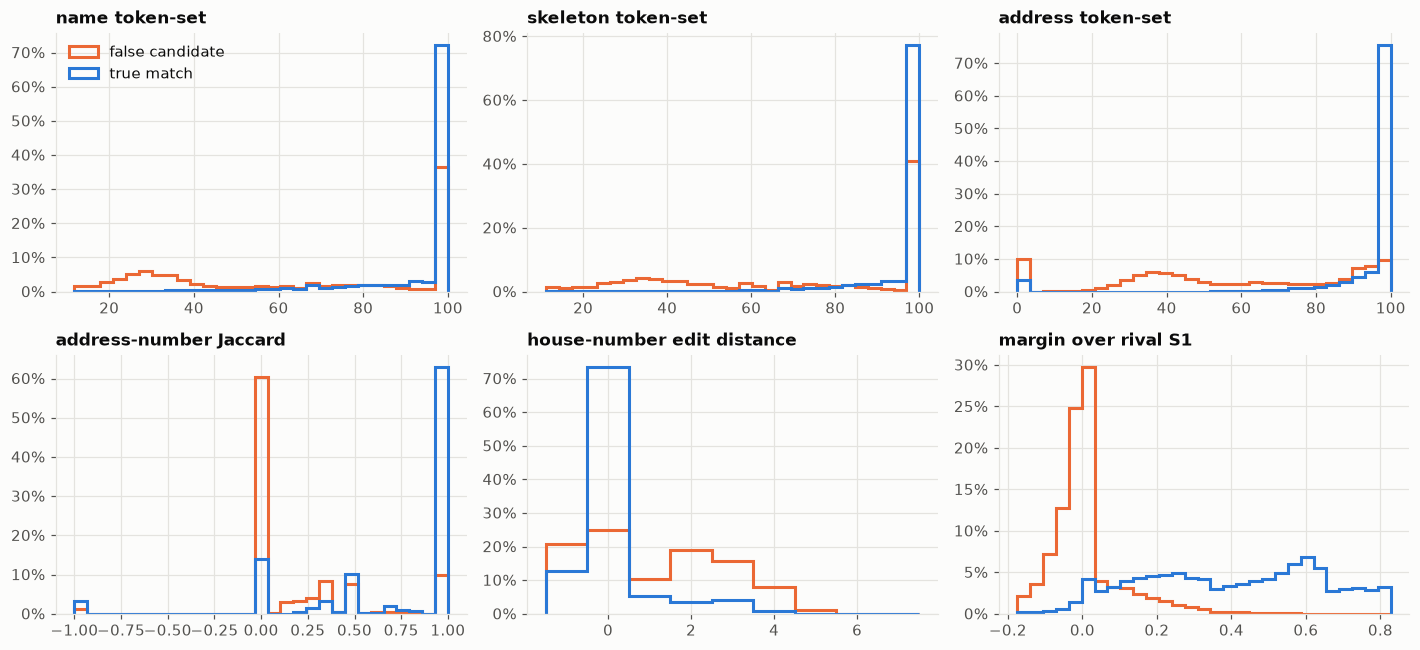

hn_lev = -1 means one side has no house number.


In [19]:
fparts = sorted(glob.glob(os.path.join(WORK_DIR, 'train_feat', '*.parquet')))
feat = pl.concat([pl.read_parquet(p) for p in fparts[:2]])
feat = feat.join(gt.with_columns(pl.lit(1).alias('y')), on=['s1_idx', 'ot_idx'], how='left').with_columns(pl.col('y').fill_null(0))
print(f'{feat.height:,} pairs, {feat["y"].mean():.1%} true;', len([c for c in feat.columns if c not in ("s1_idx", "ot_idx", "y")]), 'columns')
show = [('nm_tset', 'name token-set'), ('sk_tset', 'skeleton token-set'), ('ad_tset', 'address token-set'),
        ('num_jacc', 'address-number Jaccard'), ('hn_lev', 'house-number edit distance'), ('margin_ot', 'margin over rival S1')]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (c, title) in zip(axes.ravel(), show):
    v = feat.select(c, 'y').drop_nulls()
    lo, hi = np.percentile(v[c].to_numpy(), [0.5, 99.5])
    bins = np.linspace(lo, hi, 30) if c not in ('hn_lev',) else np.arange(-1.5, 8.5, 1)
    for yv, color, lab in ((0, ORANGE, 'false candidate'), (1, BLUE, 'true match')):
        x = v.filter(pl.col('y') == yv)[c].to_numpy()
        ax.hist(np.clip(x, bins[0], bins[-1]), bins, histtype='step', lw=2, color=color, weights=np.full(len(x), 1 / len(x)), label=lab)
    ax.set_title(title); ax.yaxis.set_major_formatter(pct)
axes[0, 0].legend(loc='upper left'); plt.tight_layout(); plt.show()
print('hn_lev = -1 means one side has no house number.')

## 7. Models and decision

Both LightGBM stages are cross-fitted on two halves of the S1 entities, so every training
prediction is **out-of-fold**. The stage-2 model adds context (competition between entities,
agreement with an entity's other confident matches) to stage-1 probabilities.

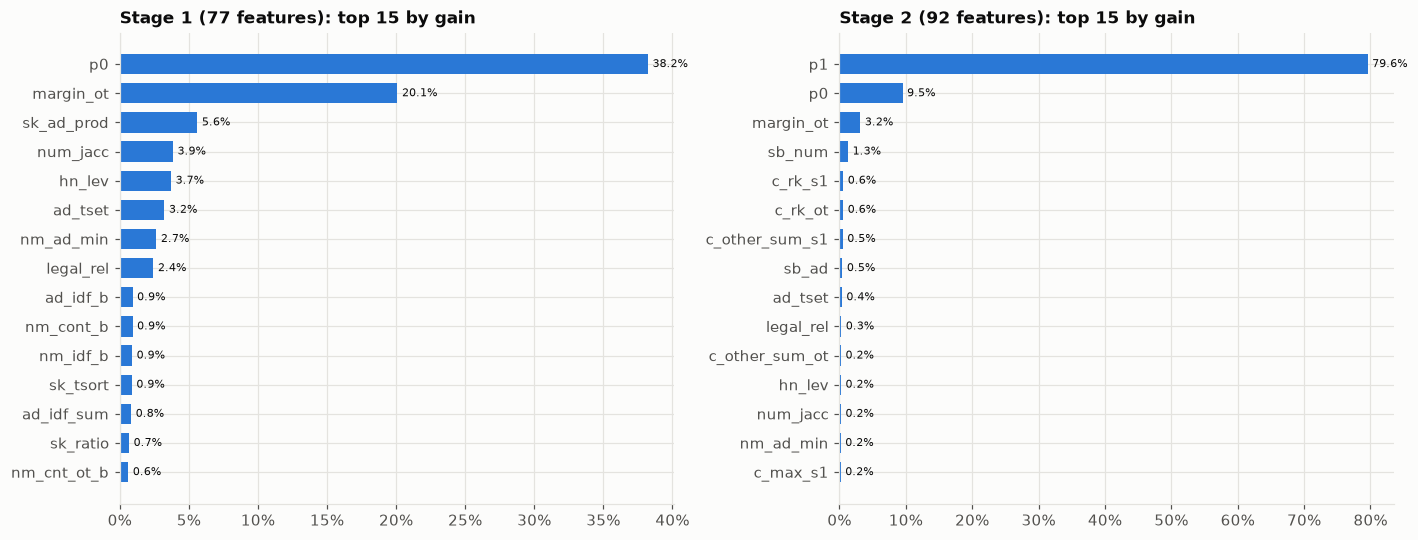

best iterations: [2145, 2728] [398, 325]


In [20]:
m1, cols1 = pickle.load(open(os.path.join(WORK_DIR, 'models', 'stage1.pkl'), 'rb'))
m2, cols2 = pickle.load(open(os.path.join(WORK_DIR, 'models', 'stage2.pkl'), 'rb'))
def gain(models, cols):
    g = np.mean([m.booster_.feature_importance('gain') for m in models], axis=0)
    return pl.DataFrame({'feature': cols, 'share': g / g.sum()}).sort('share', descending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (models, cols, title) in zip(axes, ((m1, cols1, f'Stage 1 ({len(cols1)} features)'), (m2, cols2, f'Stage 2 ({len(cols2)} features)'))):
    g = gain(models, cols).head(15)[::-1]
    bars = ax.barh(g['feature'], g['share'], 0.7, color=BLUE)
    for b in bars:
        ax.annotate(f'{b.get_width():.1%}', (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(3, 0), textcoords='offset points', va='center', fontsize=7.5)
    ax.xaxis.set_major_formatter(pct); ax.set_title(title + ': top 15 by gain')
plt.tight_layout(); plt.show()
print('best iterations:', [m.best_iteration_ for m in m1], [m.best_iteration_ for m in m2])

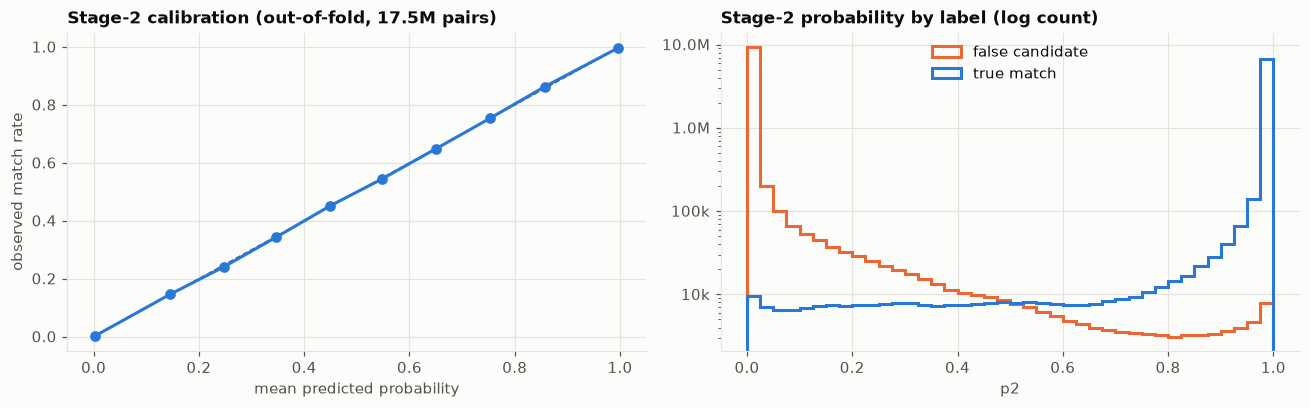

shape: (10, 4)
┌─────┬──────────┬──────────┬─────────┐
│ b   ┆ pred     ┆ obs      ┆ len     │
│ --- ┆ ---      ┆ ---      ┆ ---     │
│ f32 ┆ f32      ┆ f64      ┆ u32     │
╞═════╪══════════╪══════════╪═════════╡
│ 0.0 ┆ 0.003087 ┆ 0.003041 ┆ 9761532 │
│ 1.0 ┆ 0.145394 ┆ 0.146417 ┆ 196569  │
│ 2.0 ┆ 0.246809 ┆ 0.240519 ┆ 125807  │
│ 3.0 ┆ 0.346654 ┆ 0.343278 ┆ 87821   │
│ 4.0 ┆ 0.449112 ┆ 0.451487 ┆ 69342   │
│ 5.0 ┆ 0.548024 ┆ 0.544438 ┆ 57766   │
│ 6.0 ┆ 0.649809 ┆ 0.648052 ┆ 47794   │
│ 7.0 ┆ 0.752525 ┆ 0.753322 ┆ 54792   │
│ 8.0 ┆ 0.856734 ┆ 0.862866 ┆ 94156   │
│ 9.0 ┆ 0.996823 ┆ 0.99714  ┆ 7016965 │
└─────┴──────────┴──────────┴─────────┘


In [21]:
p1 = pl.read_parquet(os.path.join(WORK_DIR, 'train_p1.parquet'))
p2 = pl.read_parquet(os.path.join(WORK_DIR, 'train_p2.parquet'))
lab = p2.join(gt.with_columns(pl.lit(1).alias('y')), on=['s1_idx', 'ot_idx'], how='left').with_columns(pl.col('y').fill_null(0))
cal = (lab.with_columns((pl.col('p') * 10).floor().clip(0, 9).alias('b')).group_by('b')
          .agg(pl.col('p').mean().alias('pred'), pl.col('y').mean().alias('obs'), pl.len()).sort('b'))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot([0, 1], [0, 1], color=INK2, lw=1, ls='--')
axes[0].plot(cal['pred'], cal['obs'], color=BLUE, lw=2, marker='o', ms=6)
axes[0].set_xlabel('mean predicted probability'); axes[0].set_ylabel('observed match rate')
axes[0].set_title('Stage-2 calibration (out-of-fold, 17.5M pairs)')
axes[1].hist(lab.filter(pl.col('y') == 0)['p'].to_numpy(), np.linspace(0, 1, 41), histtype='step', lw=2, color=ORANGE, label='false candidate', log=True)
axes[1].hist(lab.filter(pl.col('y') == 1)['p'].to_numpy(), np.linspace(0, 1, 41), histtype='step', lw=2, color=BLUE, label='true match', log=True)
axes[1].set_title('Stage-2 probability by label (log count)'); axes[1].set_xlabel('p2'); axes[1].legend(loc='upper center')
axes[1].yaxis.set_major_formatter(thousands)
plt.tight_layout(); plt.show()
print(cal)

### Decision rules compared (exact competition metric, all 2.2M training entities)

`one_to_one` gives each S2/S3 record to at most one entity. `select_matches` picks, per
entity, the number K of top candidates that maximises the **expected** F0.5 under the
model's probabilities (K = 0 means predict nothing).

stage 1, p >= 0.5, one owner         macro F0.5 = 0.96167


stage 2, p >= 0.5, no owner rule     macro F0.5 = 0.96619


stage 2, p >= 0.7, one owner         macro F0.5 = 0.96765


stage 2, expected-F0.5 (final)       macro F0.5 = 0.96819


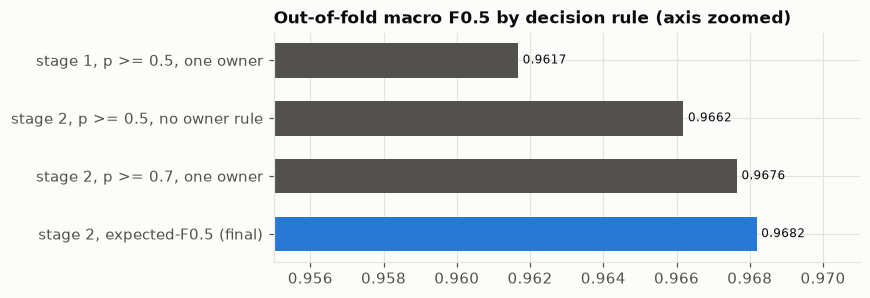

In [22]:
ids = s1_meta['idx'].to_numpy()
cfg = json.load(open(os.path.join(WORK_DIR, 'models', 'decision.json')))
rules = [
    ('stage 1, p >= 0.5, one owner', threshold_matches(one_to_one(p1, 'argmax'), 0.5)),
    ('stage 2, p >= 0.5, no owner rule', threshold_matches(p2, 0.5)),
    ('stage 2, p >= 0.7, one owner', threshold_matches(one_to_one(p2, 'renorm'), 0.7)),
    ('stage 2, expected-F0.5 (final)', select_matches(one_to_one(p2, cfg['o2o']), miss_rate=cfg['miss'])),
]
res = []
for name, pred in rules:
    f, d = macro_f05(pred, gt, ids)
    res.append((name, f)); print(f'{name:<36} macro F0.5 = {f:.5f}')
final_pred, final_d = rules[-1][1], d
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh([r[0] for r in res][::-1], [r[1] for r in res][::-1], 0.6, color=[BLUE, INK2, INK2, INK2])
for b in bars:
    ax.annotate(f'{b.get_width():.4f}', (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(3, 0), textcoords='offset points', va='center', fontsize=8)
ax.set_xlim(0.955, 0.971); ax.set_title('Out-of-fold macro F0.5 by decision rule (axis zoomed)')
plt.tight_layout(); plt.show()

## 8. Results

macro F0.5 = 0.9682   micro precision = 0.9938   micro recall = 0.9307


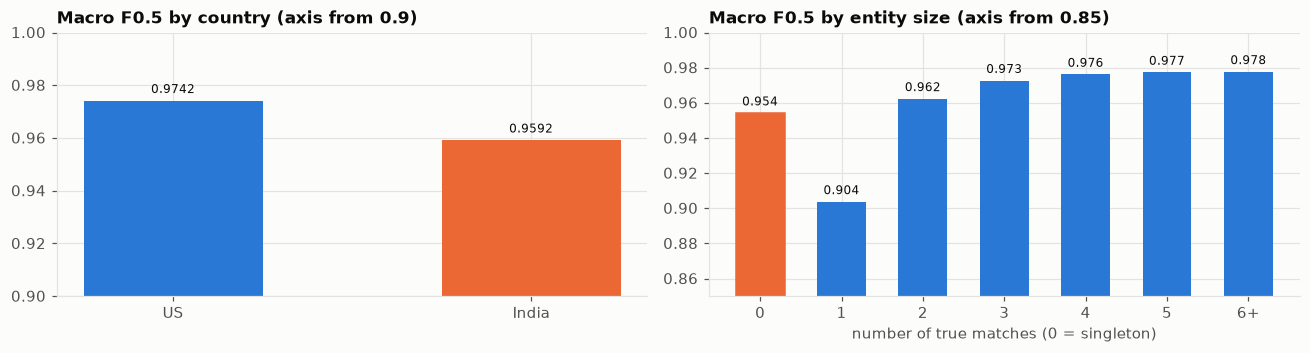

In [23]:
d = final_d.join(s1_meta.rename({'idx': 's1_idx'}), on='s1_idx')
tp, npred, nt = d['tp'].sum(), d['np'].sum(), d['nt'].sum()
print(f'macro F0.5 = {d["f"].mean():.4f}   micro precision = {tp / npred:.4f}   micro recall = {tp / nt:.4f}')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.3))
bc = d.group_by('country').agg(pl.col('f').mean(), pl.len()).sort('country', descending=True)
bars = axes[0].bar(bc['country'], bc['f'], 0.5, color=[COUNTRY_COLOR[c] for c in bc['country']])
label_bars(axes[0], bars, '{:.4f}'); axes[0].set_ylim(0.9, 1); axes[0].set_title('Macro F0.5 by country (axis from 0.9)')
bn = d.group_by(pl.col('nt').clip(0, 6).alias('k')).agg(pl.col('f').mean(), pl.len()).sort('k')
bars = axes[1].bar([('6+' if k == 6 else str(k)) for k in bn['k']], bn['f'], 0.6, color=BLUE)
bars[0].set_color(ORANGE)
label_bars(axes[1], bars, '{:.3f}'); axes[1].set_ylim(0.85, 1); axes[1].set_xlabel('number of true matches (0 = singleton)')
axes[1].set_title('Macro F0.5 by entity size (axis from 0.85)')
plt.tight_layout(); plt.show()

shape: (6, 4)
┌─────────────────┬──────────┬───────────────┬──────────────┐
│ slice           ┆ share    ┆ in candidates ┆ final recall │
│ ---             ┆ ---      ┆ ---           ┆ ---          │
│ str             ┆ f64      ┆ f64           ┆ f64          │
╞═════════════════╪══════════╪═══════════════╪══════════════╡
│ all             ┆ 1.0      ┆ 0.959893      ┆ 0.930719     │
│ Latin name      ┆ 0.927833 ┆ 0.967445      ┆ 0.937304     │
│ non-Latin name  ┆ 0.072167 ┆ 0.862802      ┆ 0.846054     │
│ domain / handle ┆ 0.047486 ┆ 0.956313      ┆ 0.953261     │
│ address present ┆ 0.95582  ┆ 0.96909       ┆ 0.950928     │
│ address missing ┆ 0.04418  ┆ 0.760921      ┆ 0.493509     │
└─────────────────┴──────────┴───────────────┴──────────────┘


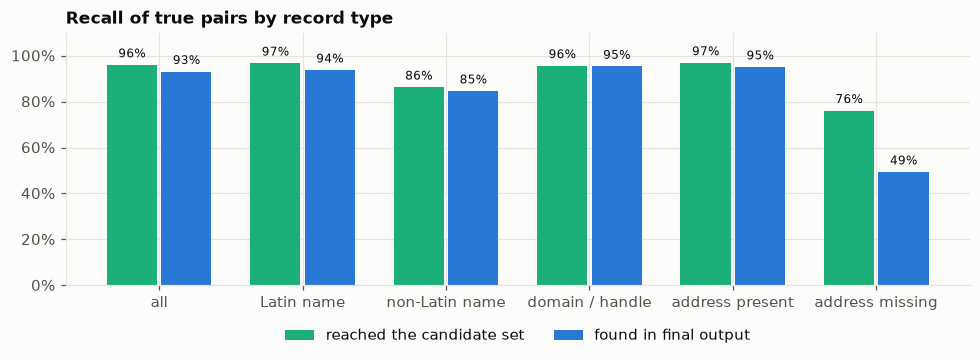

In [24]:
ot_q = (pl.scan_parquet(norm_path('train', 'oth'))
          .select(pl.col('idx').cast(pl.UInt32).alias('ot_idx'), 'nonlatin', 'is_dom', (pl.col('ad') == '').alias('no_addr')).collect())
hit = gt.join(final_pred.cast({'s1_idx': pl.UInt32, 'ot_idx': pl.UInt32}).with_columns(pl.lit(True).alias('hit')), on=['s1_idx', 'ot_idx'], how='left') \
        .join(pf.with_columns(pl.lit(True).alias('cand')), on=['s1_idx', 'ot_idx'], how='left').join(ot_q, on='ot_idx') \
        .with_columns(pl.col('hit').fill_null(False), pl.col('cand').fill_null(False))
slices = [('all', pl.lit(True)), ('Latin name', ~pl.col('nonlatin')), ('non-Latin name', pl.col('nonlatin')),
          ('domain / handle', pl.col('is_dom')), ('address present', ~pl.col('no_addr')), ('address missing', pl.col('no_addr'))]
tab = pl.DataFrame([{'slice': n, 'share': hit.filter(e).height / hit.height,
                     'in candidates': hit.filter(e)['cand'].mean(), 'final recall': hit.filter(e)['hit'].mean()} for n, e in slices])
print(tab)
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(tab.height); w = 0.38
b1 = ax.bar(x - w / 2, tab['in candidates'], w * 0.92, color=AQUA, label='reached the candidate set')
b2 = ax.bar(x + w / 2, tab['final recall'], w * 0.92, color=BLUE, label='found in final output')
label_bars(ax, b1, '{:.0%}'); label_bars(ax, b2, '{:.0%}')
ax.set_xticks(x, tab['slice']); ax.set_ylim(0, 1.1); ax.yaxis.set_major_formatter(pct)
ax.set_title('Recall of true pairs by record type'); ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncols=2)
plt.tight_layout(); plt.show()

### Test-set predictions, including France (unseen in training)

shape: (3, 4)
┌─────────┬──────────┬────────────┬────────────────────┐
│ country ┆ entities ┆ empty rate ┆ matches per entity │
│ ---     ┆ ---      ┆ ---        ┆ ---                │
│ str     ┆ u32      ┆ f64        ┆ f64                │
╞═════════╪══════════╪════════════╪════════════════════╡
│ France  ┆ 259452   ┆ 0.050341   ┆ 3.351379           │
│ India   ┆ 809986   ┆ 0.06127    ┆ 3.233607           │
│ US      ┆ 663106   ┆ 0.058149   ┆ 3.333107           │
└─────────┴──────────┴────────────┴────────────────────┘


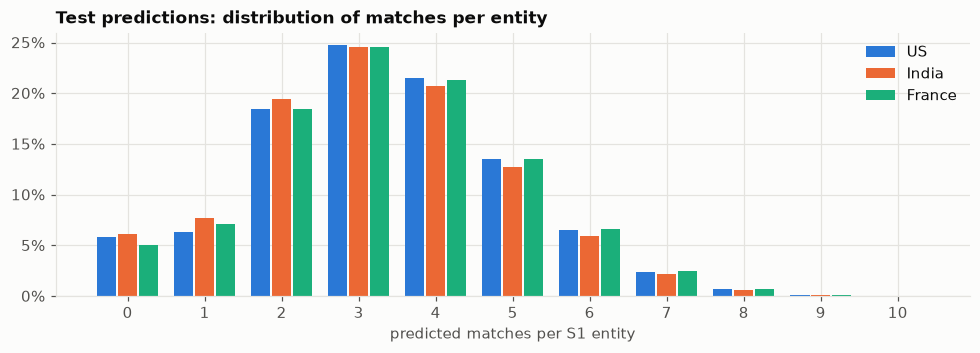

In [25]:
mr = pl.read_csv(os.path.join(OUT_DIR, 'matching_results.tsv'), separator='\t', quote_char=None, infer_schema=False) \
       .with_columns(pl.col('matched_entity_ids').fill_null(''))
t1 = pl.scan_parquet(norm_path('test', 's1')).select('entity_id', 'country').collect()
mr = mr.join(t1, left_on='source1_entity_id', right_on='entity_id').with_columns(
     pl.when(pl.col('matched_entity_ids') == '').then(0).otherwise(pl.col('matched_entity_ids').str.count_matches(',') + 1).alias('k'))
print(mr.group_by('country').agg(pl.len().alias('entities'), (pl.col('k') == 0).mean().alias('empty rate'),
                                 pl.col('k').mean().alias('matches per entity')).sort('country'))
fig, ax = plt.subplots(figsize=(9, 3.3))
ks_ = np.arange(0, 11); w = 0.27
for i, c in enumerate(('US', 'India', 'France')):
    v = mr.filter(pl.col('country') == c)['k'].to_numpy()
    ax.bar(ks_ + (i - 1) * w, [(v == k).mean() for k in ks_], w * 0.92, color=COUNTRY_COLOR[c], label=c)
ax.set_xticks(ks_); ax.yaxis.set_major_formatter(pct); ax.set_xlabel('predicted matches per S1 entity')
ax.set_title('Test predictions: distribution of matches per entity'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Worked example: Tirupati Power (S1-271585788)

Every stage for one entity. 69 different S1 entities share this exact name, and a decoy
"Tirupati Power Limited" sits in the same building (unit "c-7d" instead of "2d").

In [26]:
I = 1096
c_ = pl.scan_parquet(os.path.join(WORK_DIR, 'train_cand', '*.parquet')).filter(pl.col('s1_idx') == I) \
       .select('ot_idx', 'sc_name', 'sc_addr', 'sc_mix', 'sc_comb').collect()
recs = pl.scan_parquet(norm_path('train', 'oth')).filter(pl.col('idx').is_in(c_['ot_idx'].implode())) \
         .select(pl.col('idx').cast(pl.UInt32).alias('ot_idx'), 'entity_id', 'business_name', 'business_address').collect()
pf0 = pl.scan_parquet(os.path.join(WORK_DIR, 'train_pf.parquet')).filter(pl.col('s1_idx') == I).select('ot_idx', 'p0').collect()
ex = (c_.join(recs, on='ot_idx').join(pf0, on='ot_idx', how='left')
        .join(p1.filter(pl.col('s1_idx') == I).select('ot_idx', pl.col('p').alias('p1')), on='ot_idx', how='left')
        .join(p2.filter(pl.col('s1_idx') == I).select('ot_idx', pl.col('p').alias('p2')), on='ot_idx', how='left')
        .join(gt.rename({'s1_idx': 'owner'}), on='ot_idx', how='left')
        .with_columns(pl.when(pl.col('owner') == I).then(pl.lit('THIS ENTITY'))
                        .when(pl.col('owner').is_null()).then(pl.lit('nobody'))
                        .otherwise(pl.lit('other entity')).alias('truth'))
        .sort('sc_comb', descending=True))
print(ex.select('entity_id', 'business_name', 'sc_comb', 'p0', 'p1', 'p2', 'truth'))

shape: (13, 7)
┌──────────────┬─────────────────────────────────────────────────┬──────────┬──────────┬──────────┬──────────┬──────────────┐
│ entity_id    ┆ business_name                                   ┆ sc_comb  ┆ p0       ┆ p1       ┆ p2       ┆ truth        │
│ ---          ┆ ---                                             ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---          │
│ str          ┆ str                                             ┆ f32      ┆ f32      ┆ f32      ┆ f32      ┆ str          │
╞══════════════╪═════════════════════════════════════════════════╪══════════╪══════════╪══════════╪══════════╪══════════════╡
│ S3-31728409  ┆ Tirupati  Power                                 ┆ 0.632979 ┆ 0.968797 ┆ 0.99989  ┆ 0.99991  ┆ THIS ENTITY  │
│ S3-103238828 ┆ Tirupati Power                                  ┆ 0.630101 ┆ 0.938591 ┆ 0.999807 ┆ 0.999806 ┆ THIS ENTITY  │
│ S3-837593931 ┆ Tirupati Power Limited                          ┆ 0.451958 ┆ 0.835954 ┆ 0.511967 ┆ 0.0

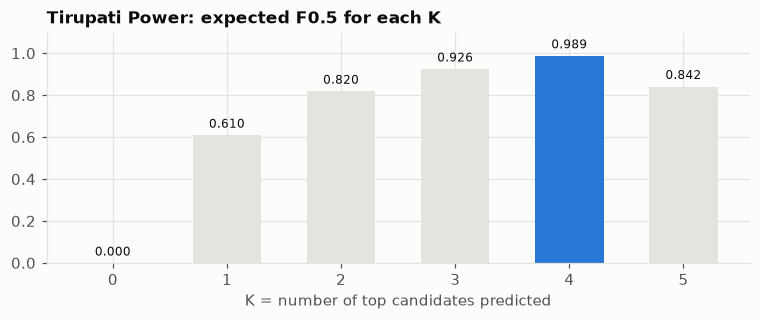

probabilities after one-owner rule: [0.9999 0.9998 0.9998 0.9957 0.0858]
chosen K = 4; predicted 4, true 4, correct 4, entity F0.5 = 1.000


In [27]:
q_ = one_to_one(p2, cfg['o2o']).filter(pl.col('s1_idx') == I).sort('p', descending=True)
P = q_.filter(pl.col('p') >= 0.01)['p'].to_numpy()[None, :]
from decision import _pb_dist
vals = [float(np.prod(1 - P) * (1 - cfg['miss']))]
for K in range(1, P.shape[1] + 1):
    Dtp = _pb_dist(P[:, :K]); Du = _pb_dist(P[:, K:]) if K < P.shape[1] else np.ones((1, 1))
    tp_ = np.arange(K + 1)[:, None]; u_ = np.arange(Du.shape[1])[None, :]; G = tp_ + u_
    extra = cfg['miss'] * G / (1 - cfg['miss'])
    with np.errstate(all='ignore'):
        Fm = np.where(tp_ > 0, 1.25 * tp_ / (0.25 * (G + extra) + K), 0)
    vals.append(float(np.einsum('et,tu,eu->e', Dtp, Fm, Du)[0]))
best = int(np.argmax(vals))
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(range(len(vals)), vals, 0.6, color=[BLUE if k == best else GRID for k in range(len(vals))])
label_bars(ax, bars, '{:.3f}'); ax.set_ylim(0, 1.1)
ax.set_xlabel('K = number of top candidates predicted'); ax.set_title('Tirupati Power: expected F0.5 for each K')
plt.tight_layout(); plt.show()
pred_i = final_pred.filter(pl.col('s1_idx') == I)
f_i = final_d.filter(pl.col('s1_idx') == I)
print('probabilities after one-owner rule:', np.round(P[0], 4))
print(f'chosen K = {best}; predicted {pred_i.height}, true {int(f_i["nt"][0])}, correct {int(f_i["tp"][0])}, entity F0.5 = {f_i["f"][0]:.3f}')

## Summary

* Out-of-fold **macro F0.5 = 0.968** on all 2.2M training entities (precision 0.994, recall
  0.931; the blocking recall ceiling is 0.960).
* Normalisation raises exact name agreement on true pairs from ~5% to ~56%. Combination keys
  raise blocking recall from 78% to 96%.
* The main remaining losses: records with **no address** (about half recovered), **non-Latin**
  names (blocking reaches 86%), and deliberate **same-building decoys** (most wrong merges).
* France test predictions look statistically like the training countries.